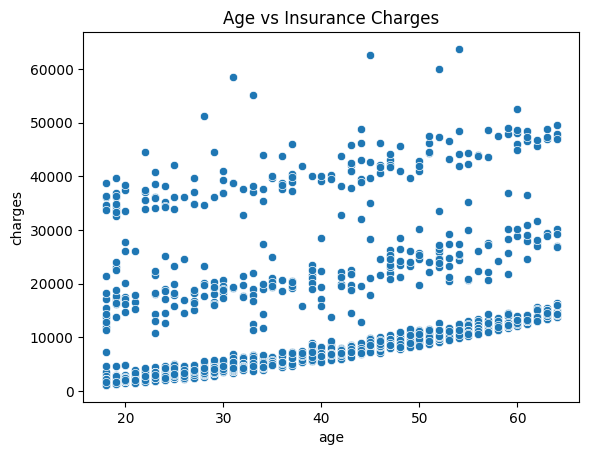

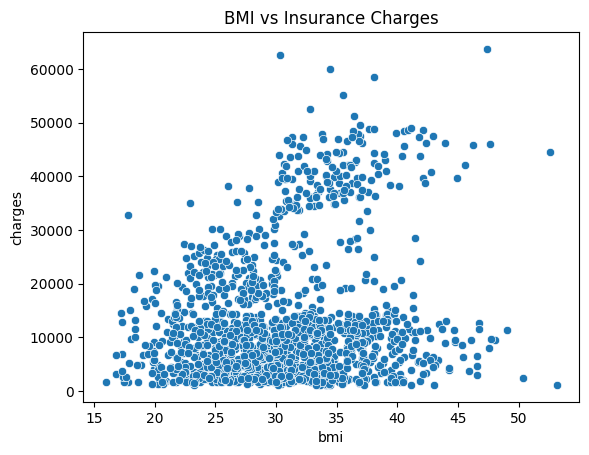

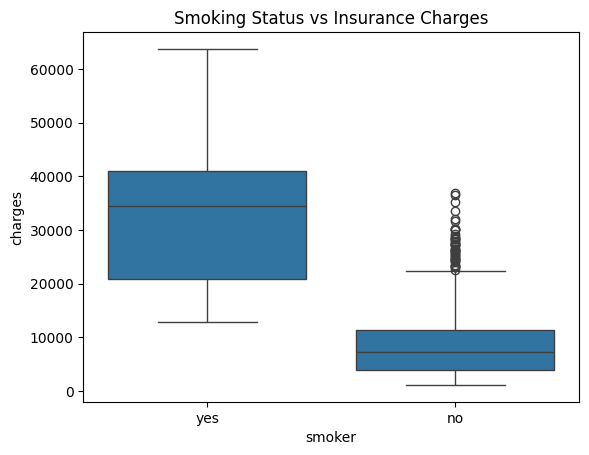

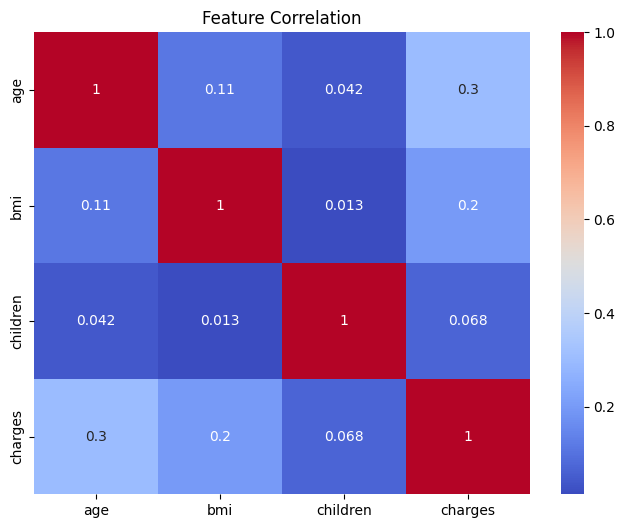

MAE: 4181.194473753654
RMSE: 5796.2846592762735


In [2]:
# =====================================
# Medical Insurance Cost Prediction
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("insurance.csv")

# -----------------------------
# Visualizations
# -----------------------------

# Age vs Charges
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Insurance Charges")
plt.show()

# BMI vs Charges
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

# Smoker vs Charges
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoking Status vs Insurance Charges")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# -----------------------------
# Encoding
# -----------------------------
df = pd.get_dummies(df, drop_first=True)

# -----------------------------
# Features & Target
# -----------------------------
X = df.drop("charges", axis=1)
y = df["charges"]

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model Training
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
